In [1]:
import pandas as pd

# Load the dataset
data_path = 'marketing_data.csv'
df = pd.read_csv(data_path)

# Display the first few rows and the columns
df


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,3/7/13,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12/3/12,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


# 1. Examine Variables Like Dt_Customer and Income:
Convert Dt_Customer to a datetime type.
Clean the Income column (remove $ and commas) and convert it to numeric. Handle missing values.

In [2]:
# Checking the data types of Dt_Customer and Income and displaying basic stats
df[['Dt_Customer', ' Income ']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Dt_Customer  2240 non-null   object
 1    Income      2216 non-null   object
dtypes: object(2)
memory usage: 35.1+ KB


In [ ]:
# Displaying unique values for Income to inspect any anomalies
df[' Income '].unique()


array(['$84,835.00 ', '$57,091.00 ', '$67,267.00 ', ..., '$46,310.00 ',
       '$65,819.00 ', '$94,871.00 '], dtype=object)

In [3]:
# Converting Dt_Customer to datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%y')

In [4]:
# Cleaning the Income column by removing '$', commas, and leading/trailing spaces, then converting to numeric
df['Income_cleaned'] = df[' Income '].str.replace('[$,]', '', regex=True).str.strip()
df['Income_cleaned'] = pd.to_numeric(df['Income_cleaned'], errors='coerce')

# Checking if the cleaning worked and inspecting the missing values
df[['Dt_Customer', 'Income_cleaned']].info(),


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Dt_Customer     2240 non-null   datetime64[ns]
 1   Income_cleaned  2216 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 35.1 KB


(None,)

In [5]:
df['Income_cleaned'].isnull().sum()

24

### 2.	There are missing income values for some customers. Conduct missing value imputation, considering that customers with similar education and marital status tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding. Specifically, scrutinize the categories of education and marital status for data cleaning.

In [6]:
# Fill missing Income values based on the median of similar groups
df['Income_cleaned'] = df.groupby(['Education', 'Marital_Status'])['Income_cleaned'].transform(lambda x: x.fillna(x.median()))


In [7]:
df['Income_cleaned'].isnull().sum()

0

3.	Create variables to represent the total number of children, age, and total spending.

a.	Derive the total purchases from the number of transactions across the three channels.


In [8]:
from datetime import datetime

# Total number of children (Kidhome + Teenhome)
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [9]:
df['Total_Children']

,Total_Children
0,0
1,0
2,1
3,2
4,1
...,...
2235,1
2236,1
2237,1
2238,0


In [10]:
# Age of the customer
df['Age'] = datetime.now().year - df['Year_Birth']

In [11]:
df['Age']

,Age
0,54
1,63
2,66
3,57
4,35
...,...
2235,48
2236,47
2237,48
2238,46


In [12]:

# Total spending on all products
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

In [14]:
df['Total_Spending']

,Total_Spending
0,1190
1,577
2,251
3,11
4,91
...,...
2235,689
2236,55
2237,309
2238,1383


In [13]:
# Total purchases across different channels
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)


### 4.	Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed

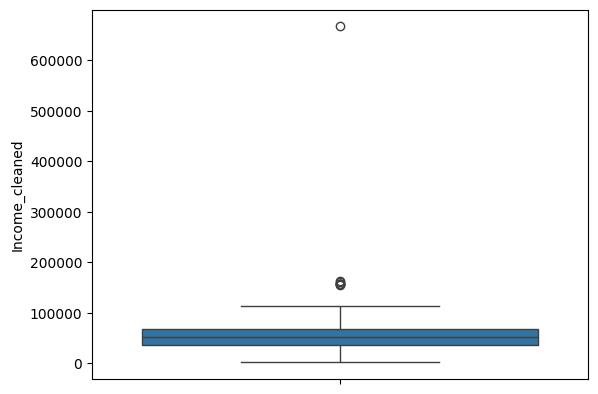

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for Income
sns.boxplot(df['Income_cleaned'])
plt.show()

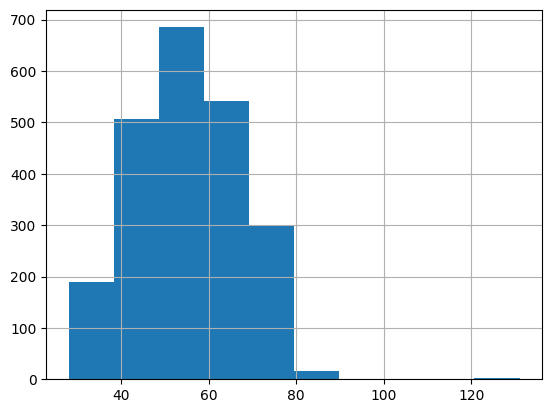

In [16]:

# Histogram for Age
df['Age'].hist(bins=10)
plt.show()

In [17]:
# Remove outliers for Income (e.g., top 1%)
q = df['Income_cleaned'].quantile(0.99)
df = df[df['Income_cleaned'] < q]


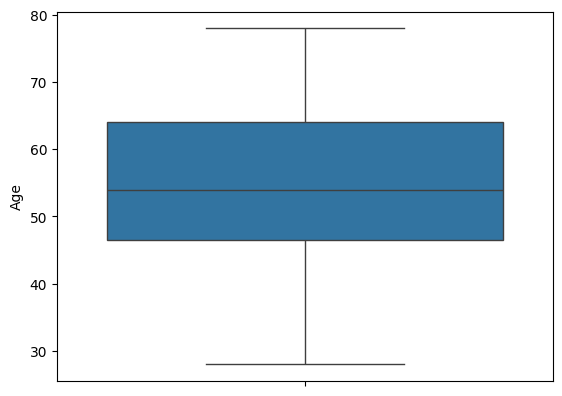

In [20]:
# Boxplot for Income
sns.boxplot(df['Age'])
plt.show()

In [19]:
# Remove outliers for Income (e.g., top 1%)
q = df['Age'].quantile(0.99)
df = df[df['Age'] < q]

## 5.	Apply ordinal and one-hot encoding based on the various types of categorical variables.

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
df['Education']

,Education
0,Graduation
1,Graduation
2,Graduation
3,Graduation
4,Graduation
...,...
2234,Graduation
2235,PhD
2236,2n Cycle
2237,Graduation


In [22]:
# Ordinal encoding for Education
education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
df['Education'] = df['Education'].astype(pd.CategoricalDtype(categories=education_order, ordered=True))
df['Education_Encoded'] = df['Education'].cat.codes

In [25]:
df['Education_Encoded']

,Education_Encoded
0,2
1,2
2,2
3,2
4,2
...,...
2234,2
2235,4
2236,1
2237,2


In [26]:
# One-hot encoding for Marital_Status
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)


# 6.	Generate a heatmap to illustrate the correlation between different pairs of variables.

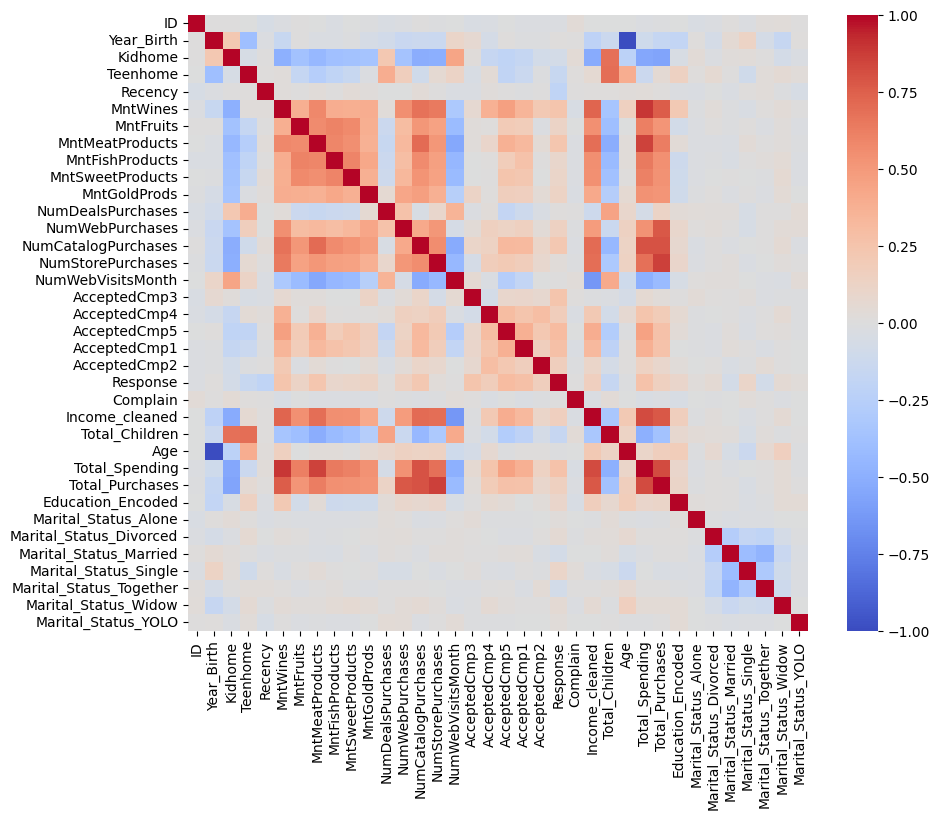

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

<Axes: xlabel='Age', ylabel='NumStorePurchases'>

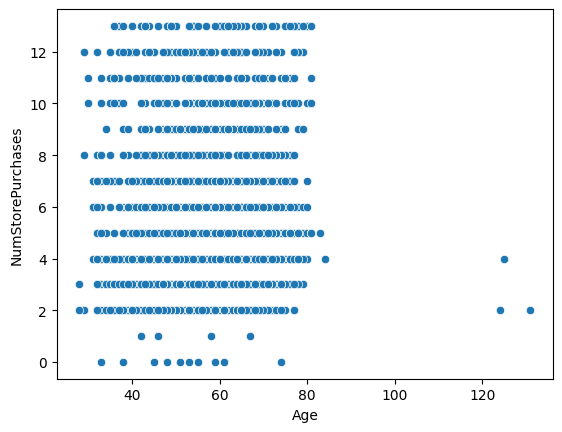

In [ ]:
#a. Older individuals and preference for in-store shopping: python # Correlation between Age and Number of Store Purchases
sns.scatterplot(x='Age', y='NumStorePurchases', data=df)

a. Older individuals may prefer in-store shopping over online shopping.
Hypotheses:

H₀: There is no difference in store purchase behavior between older and younger individuals.

H₁: Older individuals tend to prefer in-store purchases.

Test to Use: Correlation Test or Independent t-test
Correlation test if you're analyzing the relationship between age (continuous variable) and store purchases.

T-test to compare two age groups (younger vs older) and their store purchase behavior.

In [29]:
# Correlation test (Age vs Store Purchases)
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Age'], df['NumStorePurchases'])
print(f'Correlation: {corr}, P-value: {p_value}')

# If p_value < 0.05, you reject the null hypothesis, indicating a significant relationship.


Correlation: 0.1346958887018676, P-value: 2.4495536738698634e-10


In [30]:
# if else rule
if p_value < 0.05:
    print("Reject the null hypothesis. There is a statistically significant relationship between age and the number of store purchases.")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant relationship between age and the number of store purchases.")

Reject the null hypothesis. There is a statistically significant relationship between age and the number of store purchases.


In [31]:
# perform Independent t-test on df['Age'], df['NumStorePurchases']
# Perform two-sample independent t-test
from scipy import stats
t_stat, p_value = stats.ttest_ind(df['Age'], df['NumStorePurchases'], alternative='greater')

# Output the results
print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value:.3f}")

# Decision based on p-value
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: Older individuals tend to prefer in-store purchases more.")
else:
    print("Fail to reject the null hypothesis: No significant difference between younger and older individuals.")


T-Statistic: 193.043
P-Value: 0.000
Reject the null hypothesis: Older individuals tend to prefer in-store purchases more.


notation for a very small number (0.00000000031609295547088634).

This means there is strong evidence against the null hypothesis. You would reject the null hypothesis and conclude that there is a statistically significant relationship between age and the number of store purchases

b. Customers with children may prefer online shopping.
Hypotheses:
H₀: Customers with and without children shop online at similar rates.
H₁: Customers with children shop online more frequently.
Test to Use: T-test
Compare customers with children (Kidhome + Teenhome > 0) to those without children (Kidhome + Teenhome = 0).

In [33]:
# Create a new column to indicate if a customer has children
df['Has_Children'] = df['Total_Children'] > 0
# Perform t-test between age groups on store purchases
from scipy.stats import ttest_ind
# Perform t-test
with_children = df[df['Has_Children']]['NumWebPurchases']
without_children = df[~df['Has_Children']]['NumWebPurchases']

t_stat, p_value = ttest_ind(with_children, without_children, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
# rule for p value
#If p_value < 0.05, you reject the null hypothesis, indicating a significant difference.

# infer the result
if p_value < 0.05:
    print("Reject the null hypothesis. Customers with children tend to shop online more frequently.")

T-statistic: -2.807301068172054, P-value: 0.005068596036646195
Reject the null hypothesis. Customers with children tend to shop online more frequently.


c. Sales at physical stores face the risk of cannibalization by online sales.
Hypotheses:
H₀: There is no correlation between store sales and online sales.
H₁: Store sales decrease as online sales increase (negative correlation).
Test to Use: Correlation Test
Use Pearson correlation to test the relationship between the number of store purchases and web purchases.

In [34]:
# Correlation test (Store Purchases vs Web Purchases)
corr, p_value = pearsonr(df['NumStorePurchases'], df['NumWebPurchases'])
print(f'Correlation: {corr}, P-value: {p_value}')


Correlation: 0.514696428122338, P-value: 1.689666954330165e-148


In [36]:
# infer result
if p_value < 0.01:
    print("Reject the null hypothesis. There is a statistically significant negative correlation between store sales and online sales.")


Reject the null hypothesis. There is a statistically significant negative correlation between store sales and online sales.


d. Does the United States outperform the rest of the world in total purchase volumes?
Hypotheses:
H₀: The total purchases in the U.S. are the same as in other countries.
H₁: The total purchases in the U.S. are higher than in other countries.
Test to Use: Independent t-test
Compare total purchases between U.S. customers and customers from other countries.

In [37]:
df['Country'].unique()

array(['SP', 'CA', 'US', 'AUS', 'GER', 'IND', 'SA', 'ME'], dtype=object)

In [38]:
# Perform t-test between U.S. and non-U.S. customers
us_customers = df[df['Country'] == 'US']['Total_Purchases']
non_us_customers = df[df['Country'] != 'US']['Total_Purchases']

In [39]:
print(f"US customers count: {us_customers.shape[0]}")
print(f"Non-US customers count: {non_us_customers.shape[0]}")

US customers count: 108
Non-US customers count: 2083


In [40]:
t_stat, p_value = ttest_ind(us_customers, non_us_customers, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')


T-statistic: 1.444303134145021, P-value: 0.15128388639900056


In [41]:
# test
if p_value < 0.05:
    print("Reject the null hypothesis. The total purchases in the U.S. are higher than in other countries.")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant difference in total purchases between the U.S. and other countries.")

Fail to reject the null hypothesis. There is no statistically significant difference in total purchases between the U.S. and other countries.


In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', ' Income ', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Response', 'Complain', 'Country', 'Income_cleaned', 'Total_Children',
       'Age', 'Total_Spending', 'Total_Purchases', 'Education_Encoded',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO', 'Has_Children'],
      dtype='object')

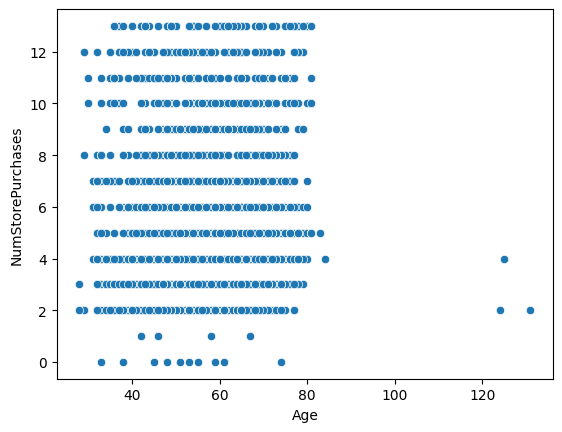

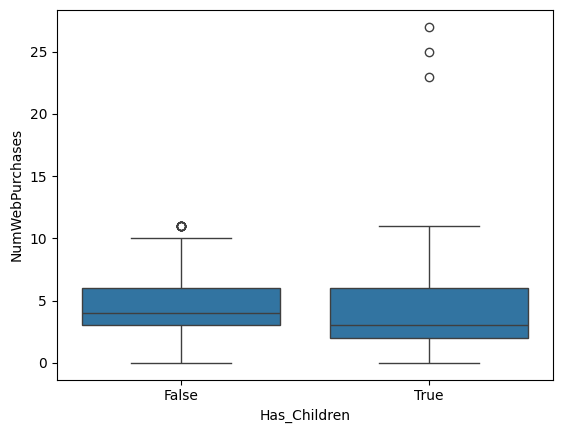

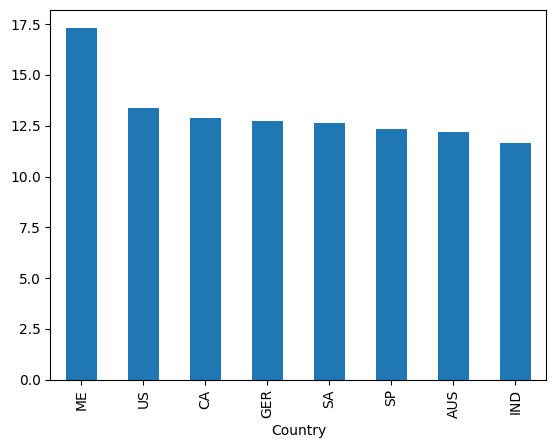

In [ ]:
# Boxplot to compare store purchases between younger and older customers
sns.scatterplot(x='Age', y='NumStorePurchases', data=df)
plt.show()

# Boxplot for web purchases by customers with and without children
sns.boxplot(x='Has_Children', y='NumWebPurchases', data=df)
plt.show()

# Bar plot for total purchases in the U.S. vs the rest of the world
df.groupby('Country')['Total_Purchases'].mean().sort_values(ascending=False).plot(kind='bar')
plt.show()

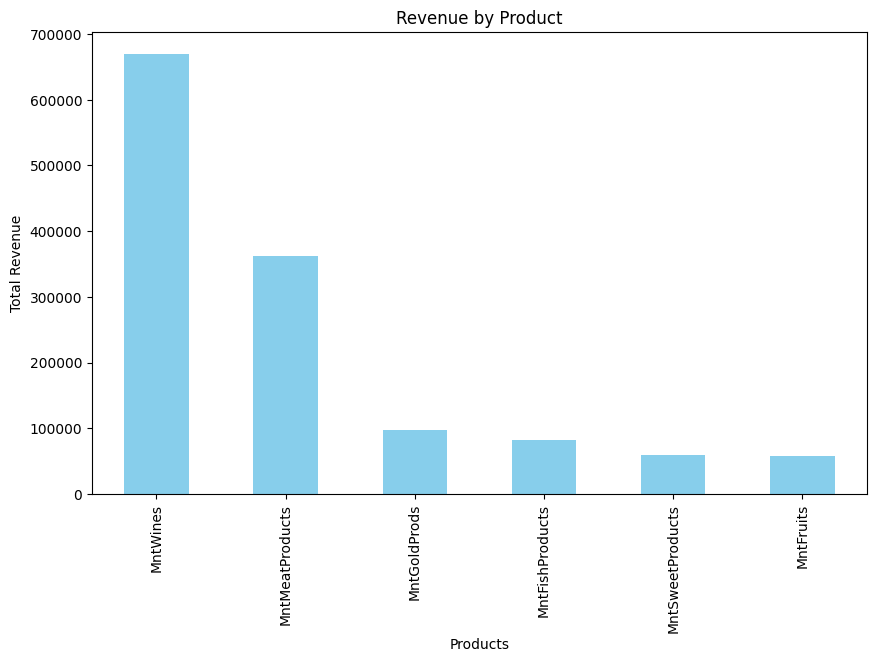

In [ ]:
# a. Top-performing products: python product_spending =
import matplotlib.pyplot as plt

# Calculate total revenue for each product
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_revenue = df[product_cols].sum()

# Sort revenues to identify top-performing and lowest-performing products
total_revenue_sorted = total_revenue.sort_values(ascending=False)

# Plot a bar chart of total revenue for each product
plt.figure(figsize=(10, 6))
total_revenue_sorted.plot(kind='bar', color='skyblue')
plt.title('Revenue by Product')
plt.xlabel('Products')
plt.ylabel('Total Revenue')
plt.show()


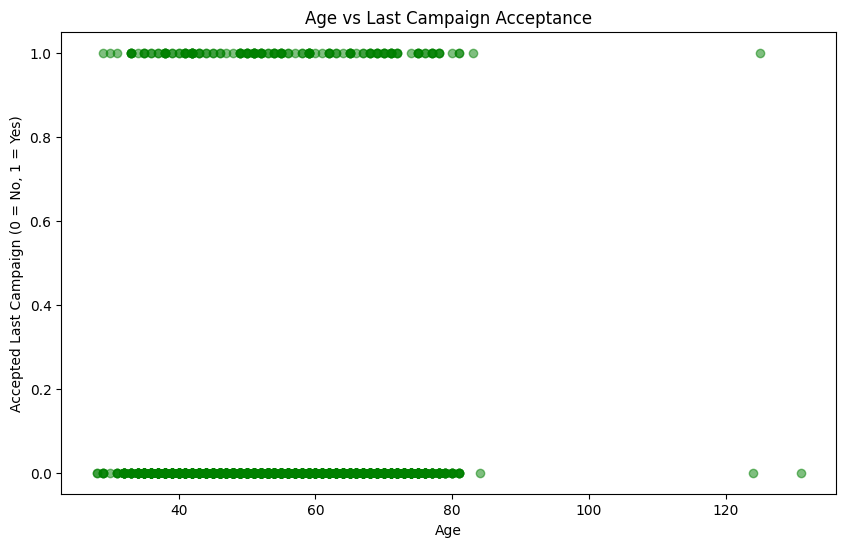

                   Age  AcceptedCmp5
Age           1.000000      0.004448
AcceptedCmp5  0.004448      1.000000


In [ ]:
# Scatter plot of Age vs Acceptance of Last Campaign
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['AcceptedCmp5'], alpha=0.5, color='green')
plt.title('Age vs Last Campaign Acceptance')
plt.xlabel('Age')
plt.ylabel('Accepted Last Campaign (0 = No, 1 = Yes)')
plt.show()

# Calculate correlation
correlation = df[['Age', 'AcceptedCmp5']].corr()
print(correlation)

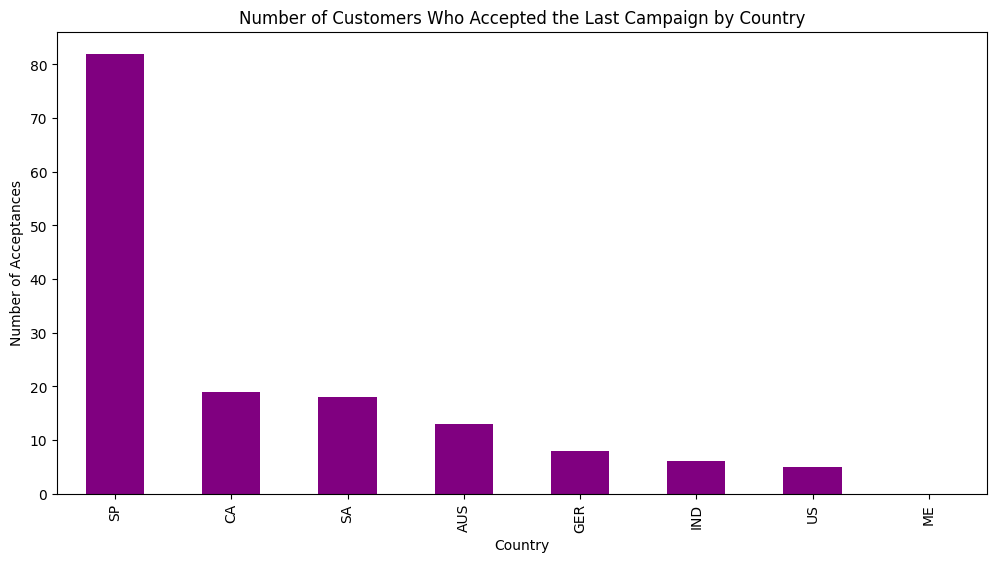

The country with the highest number of campaign acceptances: SP


In [ ]:
# Group by country and calculate the sum of accepted campaigns
campaign_acceptance_by_country = df.groupby('Country')['AcceptedCmp5'].sum()

# Plot a bar chart
plt.figure(figsize=(12, 6))
campaign_acceptance_by_country.sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Number of Customers Who Accepted the Last Campaign by Country')
plt.xlabel('Country')
plt.ylabel('Number of Acceptances')
plt.show()

# Print the country with the highest number of acceptances
top_country = campaign_acceptance_by_country.idxmax()
print(f"The country with the highest number of campaign acceptances: {top_country}")


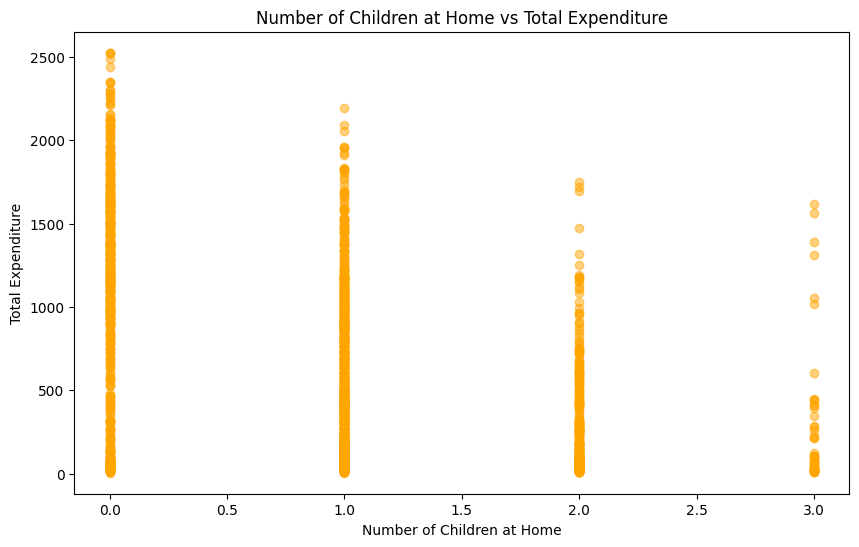

                Total_Children  Total_Spending
Total_Children        1.000000       -0.496673
Total_Spending       -0.496673        1.000000


In [ ]:
# Scatter plot: Number of Children vs Total Expenditure
plt.figure(figsize=(10, 6))
plt.scatter(df['Total_Children'], df['Total_Spending'], alpha=0.5, color='orange')
plt.title('Number of Children at Home vs Total Expenditure')
plt.xlabel('Number of Children at Home')
plt.ylabel('Total Expenditure')
plt.show()

# Calculate correlation
correlation_children_expenditure = df[['Total_Children', 'Total_Spending']].corr()
print(correlation_children_expenditure)


In [ ]:
df.columns

Index(['ID', 'Year_Birth', 'Education', ' Income ', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Response', 'Complain', 'Country', 'Income_cleaned', 'Total_Children',
       'Age', 'Total_Spending', 'Total_Purchases', 'Education_Encoded',
       'Marital_Status_Alone', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow',
       'Marital_Status_YOLO', 'Has_Children'],
      dtype='object')

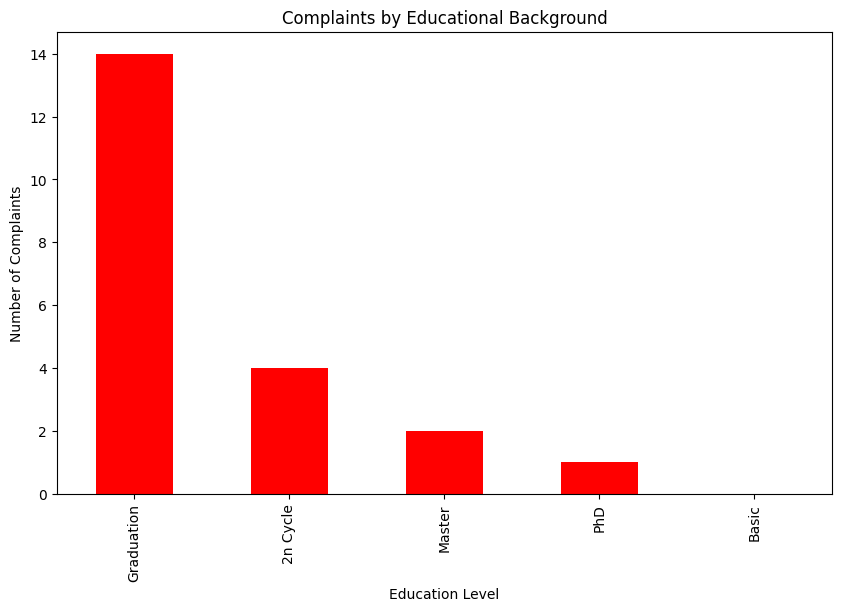

In [ ]:
# Filter customers who lodged complaints
complaints_education = df[df['Complain'] > 0]['Education'].value_counts()

# Plot a bar chart for complaints by education
plt.figure(figsize=(10, 6))
complaints_education.plot(kind='bar', color='red')
plt.title('Complaints by Educational Background')
plt.xlabel('Education Level')
plt.ylabel('Number of Complaints')
plt.show()
